# HW4: Palmer Penguins — Summary Statistics & Plots

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

In [2]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [3]:
# a
penguins.shape

(344, 8)

In [4]:
# b
penguins.dtypes

species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object

In [5]:
# c
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [6]:
# d
penguins.groupby("species").count()
# There are 152 Adelie, 68 Chinstrap, and 124 Gentoo penguins.

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
species,,,,,,,
Adelie,152,151,151,151,151,146,152
Chinstrap,68,68,68,68,68,68,68
Gentoo,124,123,123,123,123,119,124


In [7]:
penguins.groupby("sex").count()
# There are 165 female penguins and 168 male penguins.

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
sex,,,,,,,
female,165,165,165,165,165,165,165
male,168,168,168,168,168,168,168


### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [8]:
# Your code here
penguins_clean = penguins.dropna(subset = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']).copy()
penguins_clean.shape

(333, 8)

### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [9]:
# Your code here
penguins_clean.describe(percentiles = [0.25, 0.50, 0.75], include = ['int64', 'float64'])

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000,333.000,333.000,333.000,333.000
mean,43.993,17.165,200.967,4207.057,2008.042
std,5.469,1.969,14.016,805.216,0.813
min,32.100,13.100,172.000,2700.000,2007.000
25%,39.500,15.600,190.000,3550.000,2007.000
50%,44.500,17.300,197.000,4050.000,2008.000
75%,48.600,18.700,213.000,4775.000,2009.000
max,59.600,21.500,231.000,6300.000,2009.000


In [10]:
# mean
penguins_clean.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.824,18.347,190.103,3706.164
Chinstrap,48.834,18.421,195.824,3733.088
Gentoo,47.568,14.997,217.235,5092.437


In [11]:
# std
penguins_clean.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].std()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,2.663,1.219,6.522,458.620
Chinstrap,3.339,1.135,7.132,384.335
Gentoo,3.106,0.986,6.585,501.476


### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [12]:
# Your code here
part_a = penguins_clean.groupby(['species', 'sex'])[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].agg(['mean', 'count'])
print(part_a)

part_a[part_a["body_mass_g"]['mean'] == part_a["body_mass_g"]['mean'].max()]

                 bill_length_mm       bill_depth_mm       flipper_length_mm  \
                           mean count          mean count              mean   
species   sex                                                                 
Adelie    female         37.258    73        17.622    73           187.795   
          male           40.390    73        19.073    73           192.411   
Chinstrap female         46.574    34        17.588    34           191.735   
          male           51.094    34        19.253    34           199.912   
Gentoo    female         45.564    58        14.238    58           212.707   
          male           49.474    61        15.718    61           221.541   

                       body_mass_g        
                 count        mean count  
species   sex                             
Adelie    female    73    3368.836    73  
          male      73    4043.493    73  
Chinstrap female    34    3527.206    34  
          male      34    3938

bill_length_mm       bill_depth_mm       flipper_length_mm        \
                       mean count          mean count              mean count   
species sex                                                                     
Gentoo  male         49.474    61        15.718    61           221.541    61   

             body_mass_g        
                    mean count  
species sex                     
Gentoo  male    5484.836    61

### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [13]:

# Your code here
penguins_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.229,0.653,0.589
bill_depth_mm,-0.229,1.000,-0.578,-0.472
flipper_length_mm,0.653,-0.578,1.000,0.873
body_mass_g,0.589,-0.472,0.873,1.000


In [14]:
penguins_clean.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
          flipper_length_mm           0.332          0.311              1.000   
          body_mass_g                 0.544          0.580              0.465   
Chinstrap bill_length_mm              1.000          0.654              0.472   
          bill_depth_mm               0.654          1.000              0.580   
          flipper_length_mm           0.472          0.580              1.000   
          body_mass_g                 0.514          0.604              0.642   
Gentoo    bill_length_mm              1.000          0.654              0.664   
          bill_depth_mm               0.654          1.000              0.711   
          flipper_length_mm           0.664          0.711              1.000   
          body_mass_g                 0.667          0.723              0.711   

                             body_mass_g  
species                                   
Adelie    bill_length_mm           0.544  
          bill_depth_mm            0.580  
          flipper_length_mm        0.465  
          body_mass_g              1.000  
Chinstrap bill_length_mm           0.514  
          bill_depth_mm            0.604  
          flipper_length_mm        0.642  
          body_mass_g              1.000  
Gentoo    bill_length_mm           0.667  
          bill_depth_mm            0.723  
          flipper_length_mm        0.711  
          body_mass_g              1.000

It seems like there's negative correlation between bill length and depth overall, but positive correlation when grouped by species.

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


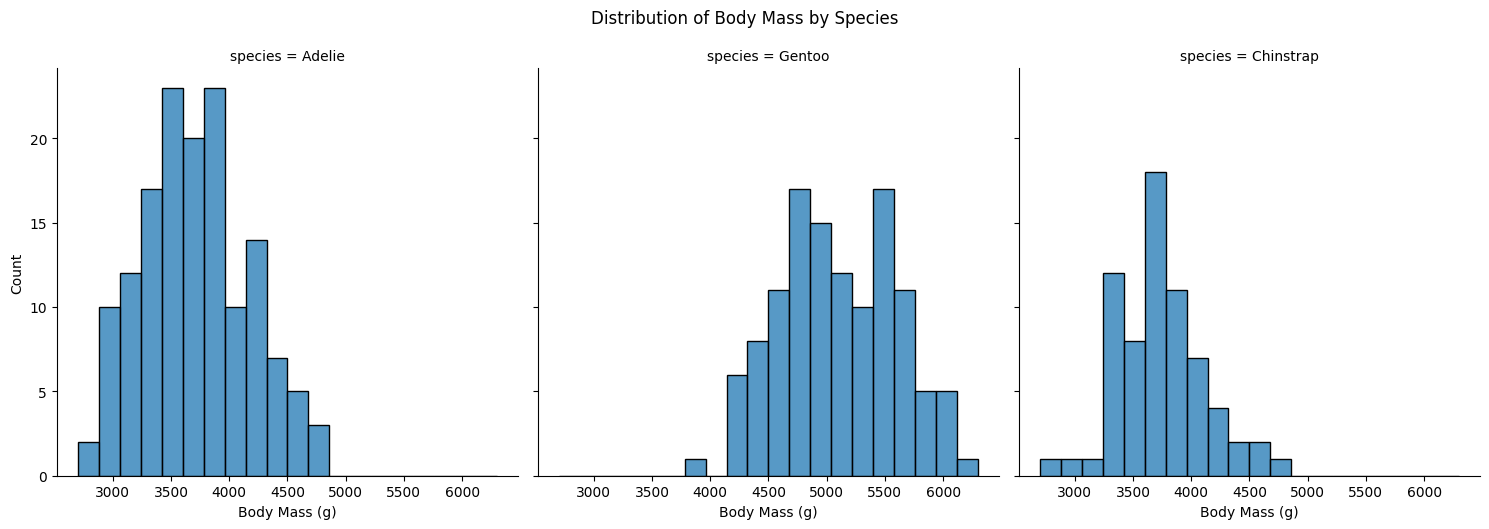

In [15]:
g = sns.displot(data = penguins_clean, x = penguins_clean['body_mass_g'], col = 'species', bins = 20)
g.figure.suptitle("Distribution of Body Mass by Species", y=1.05) # y=1.05 prevents overlap
g.set_axis_labels("Body Mass (g)")


### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

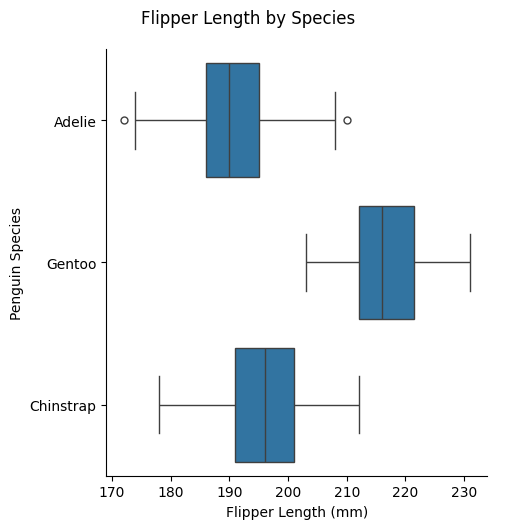

In [16]:
flip = sns.catplot(data= penguins_clean, x= "flipper_length_mm", y="species", kind="box") 
flip.set_xlabels("Flipper Length (mm)")
flip.set_ylabels("Penguin Species")
flip.figure.suptitle("Flipper Length by Species", y = 1.05)
plt.show()

In [17]:
penguins_clean.groupby('species')['flipper_length_mm'].median()

species
Adelie       190.0
Chinstrap    196.0
Gentoo       216.0
Name: flipper_length_mm, dtype: float64

Overall, the Gentoo species has a much higher median than the other two species. The spreads look fairly similar in distance from the median, and I can see that there are some outliers in the Adelie species. The fact that Gentoo is the largest, while the other two are fairly similar, matches up with the findings earlier that Gentoo species is also the heaviest on average.

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

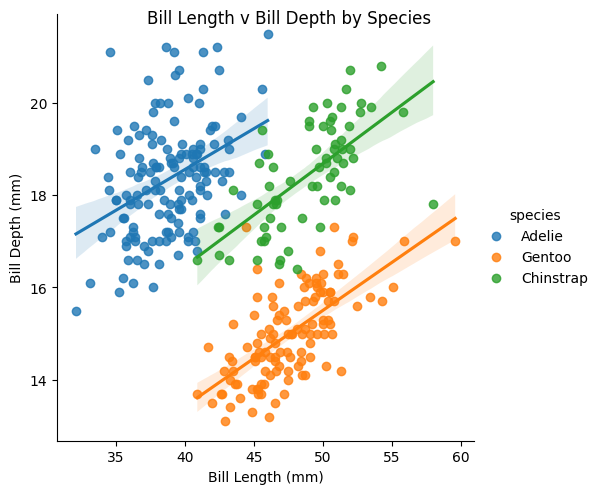

In [18]:
scat = sns.lmplot(data = penguins_clean, x="bill_length_mm", y="bill_depth_mm", hue = "species")
scat.set_axis_labels("Bill Length (mm)", "Bill Depth (mm)")
scat.figure.suptitle("Bill Length v Bill Depth by Species")
plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

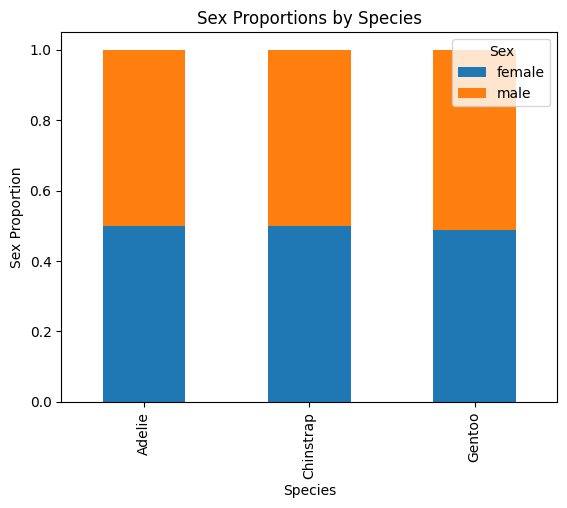

In [19]:
proportions = penguins_clean.groupby('species')['sex'].value_counts(normalize=True).unstack()

proportions.plot(kind='bar', stacked=True)
plt.xlabel('Species')
plt.ylabel('Sex Proportion')
plt.title('Sex Proportions by Species')
plt.legend(title='Sex')
plt.show()